In [1]:


import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from confidence.unsupervised.classic.SHE import SHETorchConfidence
from confidence.unsupervised.classic.dice import DICEConfidence
from confidence.unsupervised.classic.lof import LOFTorchConfidence
from model.classifier import Classifier, MyProgressBar
from utils.transforms.apply import grid_resample,grid_resample_border,grid_resample_reflection

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#look for experiment files in parents
import os
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)


In [3]:
experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")

In [4]:
print(experiment_files_path_data)

C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\data


In [5]:
os.path.join(experiment_files_path_data, "ecuador-moths-master")

'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\data\\ecuador-moths-master'

In [6]:
#check path existence
os.path.exists(os.path.join(experiment_files_path_data, "ecuador-moths-master"))

True

In [17]:
from utils.affine_transforms import AffineTransformation2D
from dataset.moths import Moths, PersistentCachedDataset
from dataset.mnist_no_pil import AffineTransformDataset

dataset = 'moths'
batch_size = 32
#divide by 255 transform
#get from modelnet resnet18
transform = torchvision.models.ResNet18_Weights.IMAGENET1K_V1.transforms()

dataset_tv = Moths(os.path.join(experiment_files_path_data, "ecuador-moths-master"),
                    train=True,transform=transform)

dataset_tv=PersistentCachedDataset(dataset_tv, cache_file=os.path.join(experiment_files_path_data, "moths_cache2"))



dataset_test_pre = Moths(os.path.join(experiment_files_path_data, "ecuador-moths-master"),
                    train=False,transform=transform)

dataset_test_pre = PersistentCachedDataset(dataset_test_pre, cache_file=os.path.join(experiment_files_path_data, "moths_test_cache2"))



dataset_train, dataset_val = torch.utils.data.random_split(dataset_tv, [int(len(dataset_tv)*0.99), len(dataset_tv)-int(len(dataset_tv)*0.99)])



transformations = [AffineTransformation2D.ROTATION.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi,torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]
n_samples = 17


#test simulated annealing
from utils.transformation_problem import TransformationProblem
from utils.transform_sequence import TransformSequence, create_parameter_sampler, create_sampler





transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=grid_resample_border,device="cpu",reflect=True,use_individual_param_correction=False)



sampler = create_sampler(transform_seq)

dataset_test = AffineTransformDataset(dataset_test_pre,sampler,return_transformation=False,batch_size=batch_size,resample_func=grid_resample_border)

transform_seq.to(device)


TransformSequence()

In [18]:
number_classes = dataset_test_pre.dataset.get_num_classes()

675

In [19]:
dataset_train_transformed = AffineTransformDataset(dataset_train,sampler,return_transformation=False,batch_size=batch_size,resample_func=grid_resample_border)
train_loader_transformed = torch.utils.data.DataLoader(dataset_train_transformed, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)

In [20]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)

In [27]:
test_loader_pre = torch.utils.data.DataLoader(dataset_test_pre, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)

In [21]:
dataset_val_transformed = AffineTransformDataset(dataset_val,sampler,return_transformation=False,batch_size=batch_size,resample_func=grid_resample_border)

val_loader_transformed = torch.utils.data.DataLoader(dataset_val_transformed, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7205882..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5356624..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5532379..2.6400006].


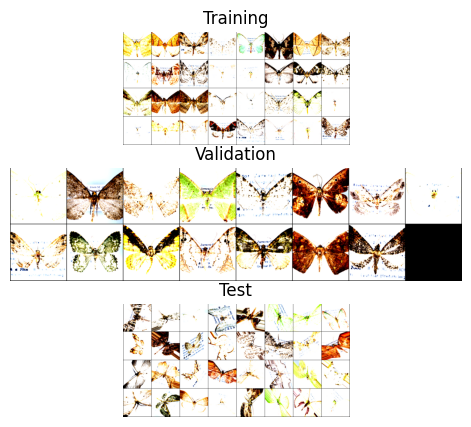

In [22]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [23]:
modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric.pth")

In [24]:
#likely need a model that can handle this as there are so few samples per class.
#making this pretty hard to work with.

In [36]:
import pytorch_lightning as pl
import os

model_path = modelpath


model = torchvision.models.resnet18(weights="IMAGENET1K_V1")
#replace the head
model.fc = nn.Linear(model.fc.in_features, number_classes)
#freeze all layers except the head
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

# Check if model is already trained
if os.path.exists(model_path) and False:
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class =  torch.optim.AdamW, optimizer_params = {"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader,test_loader_pre)

    #unfreeze all layers
    for param in model.parameters():
        param.requires_grad = True
    # Train again with lower learning rate
    trainer2 = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    trainer2.fit(lightning_model, train_loader,test_loader_pre)

    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

Using 16bit Automatic Mixed Precision (AMP)
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type   | Params | Mode 
-----------------------------------------
0 | model | ResNet | 11.5 M | train
-----------------------------------------
346 K     Trainable params
11.2 M    Non-trainable params
11.5 M    Total params
46.091    Total estimated model params size (MB)
68        Modules in train mode
0         Modules in eval mode


Training model and will save to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\moths_metric.pth
Epoch 29: 100%|██████████| 45/45 [00:01<00:00, 38.50it/s, v_num=626, train_loss=0.0633, val_loss=2.690, val_acc=0.450]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 45/45 [00:01<00:00, 34.77it/s, v_num=626, train_loss=0.0633, val_loss=2.690, val_acc=0.450]


Using 16bit Automatic Mixed Precision (AMP)
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type   | Params | Mode 
-----------------------------------------
0 | model | ResNet | 11.5 M | train
-----------------------------------------
11.5 M    Trainable params
0         Non-trainable params
11.5 M    Total params
46.091    Total estimated model params size (MB)
68        Modules in train mode
0         Modules in eval mode


Epoch 29: 100%|██████████| 45/45 [00:01<00:00, 24.48it/s, v_num=627, train_loss=0.000746, val_loss=1.810, val_acc=0.593]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 45/45 [00:02<00:00, 20.04it/s, v_num=627, train_loss=0.000746, val_loss=1.810, val_acc=0.593]
Model saved to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\moths_metric.pth


In [13]:
#calibrate the model
#from confidence.calibration import TemperatureCalibrationModule
#if model is not temperature calibrated
#if isinstance(model, TemperatureCalibrationModule):
    #model = model.model
#model = TemperatureCalibrationModule(model,per_logit=True).cuda()
#model.fit(test_loader)


In [14]:
model.cuda().eval()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=3136, out_features=128, bias=True)
  (10): Dropout(p=0.5, inplace=False)
  (11): GELU(approximate='none')
  (12): Linear(in_features=128, out_features=10, bias=True)
)

In [15]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 0.9922.


In [16]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

Mean accuracy on the transformed test set: 0.4104.


In [17]:
from pytorch_lightning.callbacks import ModelCheckpoint
import pytorch_lightning as pl
import os
import torch
import torch.nn as nn

modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric3.pth")
model_path = modelpath

model2 = nn.Sequential(
    nn.Conv2d(1, 128, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(128),
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(256),
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(256),
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(256 * 3 * 3, 128),
    torch.nn.Dropout(0.5),
    nn.GELU(),
    nn.Linear(128, n_classes)
)

if os.path.exists(model_path) and True:
    print(f"Loading model from {model_path}")
    model2.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")

    # LightningModule wrapper
    lightning_model = Classifier(
        model2,
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # Callbacks
    progress_bar     = MyProgressBar()
    checkpoint_callback = ModelCheckpoint(
        monitor='val_acc',
        mode='max',
        save_top_k=1,
        verbose=True,
        dirpath=os.path.join(os.getcwd(), "model"),
        filename=f"{dataset}_val_acc_best"
    )

    # Trainer
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar, checkpoint_callback],
    )

    # Train
    trainer.fit(lightning_model, train_loader_transformed, val_loader_transformed)

    # 1) Reload LightningModule from best ckpt
    best_ckpt = checkpoint_callback.best_model_path
    print(f"Best Lightning checkpoint: {best_ckpt}")

    lightning_model = Classifier.load_from_checkpoint(
        best_ckpt,
        model=model2,  # supply same nn.Sequential structure
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # 2) Extract & save raw nn.Sequential weights
    model2.load_state_dict(lightning_model.model.state_dict())
    torch.save(model2.state_dict(), model_path)
    print(f"Best model saved to {model_path}")


with torch.no_grad():
    model2.eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model2(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

model2 = None
torch.cuda.empty_cache()


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


Training model and will save to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\mnist_metric3.pth


C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:654: Checkpoint directory C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | Sequential | 1.2 M  | train
---------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.737     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 469/469 [00:07<00:00, 60.25it/s, v_num=276, val_loss=0.409, val_acc=0.868]

Epoch 0, global step 469: 'val_acc' reached 0.86820 (best 0.86820), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_notebooks\\comparision_metrics\\model\\mnist_val_acc_best-v6.ckpt' as top 1


...

Epoch 28: 100%|██████████| 469/469 [00:05<00:00, 92.87it/s, v_num=276, val_loss=0.268, val_acc=0.950]

Epoch 28, global step 13601: 'val_acc' was not in top 1


Epoch 29: 100%|██████████| 469/469 [00:04<00:00, 99.18it/s, v_num=276, val_loss=0.286, val_acc=0.950] 

Epoch 29, global step 14070: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 469/469 [00:04<00:00, 99.12it/s, v_num=276, val_loss=0.286, val_acc=0.950]
Best Lightning checkpoint: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\mnist_val_acc_best-v6.ckpt
Best model saved to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\mnist_metric3.pth
Mean accuracy on the transformed test set: 0.9494.


In [18]:
modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric2.pth")
import pytorch_lightning as pl
import os

model_path = modelpath

model2 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(64),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, n_classes)
)

if os.path.exists(model_path) and True:
    print(f"Loading model from {model_path}")
    model2.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")

    # LightningModule wrapper
    lightning_model = Classifier(
        model2,
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # Callbacks
    progress_bar     = MyProgressBar()
    checkpoint_callback = ModelCheckpoint(
        monitor='val_acc',
        mode='max',
        save_top_k=1,
        verbose=True,
        dirpath=os.path.join(os.getcwd(), "model"),
        filename=f"{dataset}_val_acc_best"
    )

    # Trainer
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar, checkpoint_callback],
    )

    # Train
    trainer.fit(lightning_model, train_loader_transformed, val_loader_transformed)

    # 1) Reload LightningModule from best ckpt
    best_ckpt = checkpoint_callback.best_model_path
    print(f"Best Lightning checkpoint: {best_ckpt}")

    lightning_model = Classifier.load_from_checkpoint(
        best_ckpt,
        model=model2,  # supply same nn.Sequential structure
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # 2) Extract & save raw nn.Sequential weights
    model2.load_state_dict(lightning_model.model.state_dict())
    torch.save(model2.state_dict(), model_path)
    print(f"Best model saved to {model_path}")

with torch.no_grad():
    model2.eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model2(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')


model2 = None
torch.cuda.empty_cache()

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | Sequential | 421 K  | train
---------------------------------------------
421 K     Trainable params
0         Non-trainable params
421 K     Total params
1.687     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


Training model and will save to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\mnist_metric2.pth
Epoch 0: 100%|██████████| 469/469 [00:06<00:00, 72.13it/s, v_num=277, val_loss=0.692, val_acc=0.774]

Epoch 0, global step 469: 'val_acc' reached 0.77400 (best 0.77400), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_notebooks\\comparision_metrics\\model\\mnist_val_acc_best-v7.ckpt' as top 1


Epoch 1: 100%|██████████| 469/469 [00:03<00:00, 146.96it/s, v_num=277, val_loss=0.473, val_acc=0.861]

Epoch 1, global step 938: 'val_acc' reached 0.86080 (best 0.86080), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_notebooks\\comparision_metrics\\model\\mnist_val_acc_best-v7.ckpt' as top 1


...

Epoch 28: 100%|██████████| 469/469 [00:03<00:00, 141.10it/s, v_num=277, val_loss=0.216, val_acc=0.941]

Epoch 28, global step 13601: 'val_acc' reached 0.94120 (best 0.94120), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_notebooks\\comparision_metrics\\model\\mnist_val_acc_best-v7.ckpt' as top 1


Epoch 29: 100%|██████████| 469/469 [00:03<00:00, 142.26it/s, v_num=277, val_loss=0.235, val_acc=0.942]

Epoch 29, global step 14070: 'val_acc' reached 0.94160 (best 0.94160), saving model to 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_notebooks\\comparision_metrics\\model\\mnist_val_acc_best-v7.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 469/469 [00:03<00:00, 141.00it/s, v_num=277, val_loss=0.235, val_acc=0.942]
Best Lightning checkpoint: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\mnist_val_acc_best-v7.ckpt
Best model saved to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\mnist_metric2.pth
Mean accuracy on the transformed test set: 0.944.


In [19]:
from confidence.utils import ModelInputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'10',flatten=True).eval()

In [20]:
#extract embeddings and fit NNDistanceConfidence()
embeddings=[]
classes =[]
from confidence.direct.logit_based import EnergyConfidence
energy_conf_module = EnergyConfidence()

logits = []

for batch in train_loader:
    emb,logit = dual_ouput_model(batch[0].cuda())
    embeddings.append(emb.detach().cpu().numpy())
    classes.append(batch[1].detach().cpu().numpy())
    logits.append(logit.detach().cpu().numpy())


embeddings = np.vstack(embeddings)
classes = np.hstack(classes)
logits = np.vstack(logits)
#randomly sample 5000 ones
if embeddings.shape[0] > 5000:
    indices = np.random.choice(embeddings.shape[0], 5000, replace=False)
    embeddings_sampled = embeddings[indices]
    classes_sampled = classes[indices]
    logits_sampled = logits[indices]
else:
    embeddings_sampled = embeddings
    classes_sampled = classes
    logits_sampled = logits


In [21]:
import search.shgo
import importlib
importlib.reload(search.shgo)

<module 'search.shgo' from 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\search\\shgo.py'>

In [22]:
di = search.shgo.SHGO(selection_method="topk")
di_no_grad = search.shgo.SHGO(selection_method="topk",local_max_steps=0)

In [23]:


from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
nn_pytorch = KNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings_sampled).cpu())
nn_pytorch.cuda()


conf_split = SplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.9354.


In [24]:
import tqdm

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
nn_pytorch = KNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings).cpu())
nn_pytorch.cuda()


conf_split = SplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0000)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for data, target in tqdm.tqdm(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

100%|██████████| 40/40 [00:11<00:00,  3.46it/s]

Mean accuracy on the transformed test set with GD: 0.945.


In [25]:


from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence,PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
nn_pytorch = PerClassKNNConfidence(metric="cosine")
nn_pytorch.fit(torch.tensor(embeddings_sampled).cpu(), y=torch.tensor(classes_sampled).cpu())
nn_pytorch.cuda()


conf_split = PredictedSplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.9334.


In [26]:


from confidence.direct.prob_based import EntropyConfidence
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence,NNGuideSplitConfidence


class one_confidence(nn.Module):
    def __init__(self):
        super().__init__()
        self.EnergyConfidence = EnergyConfidence()

    def forward(self, x,y=None):
        return torch.ones_like(x)[:,0]

class one_confidence2(nn.Module):
    def __init__(self):
        super().__init__()
        self.EnergyConfidence = EnergyConfidence()

    def forward(self, x,y=None):
        return self.EnergyConfidence(x,y)

conf_split = NNGuideSplitConfidence(one_confidence2(), k=3)
conf_split.fit((torch.tensor(embeddings_sampled).cpu(), torch.tensor(logits_sampled).cpu()))
conf_split.cuda()
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7558.


In [27]:
nn_pytorch.save("test.pth")
nn_pytorch.load("test.pth")

In [28]:
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7516.


In [29]:
problem_nn_pytorch.calculate_error(data.cuda(), torch.zeros(data.shape[0],5).cuda())

(tensor([ -96.6803, -103.0657, -177.5276,  -76.7998,  -66.4391,  -53.0684,
         -419.9775, -126.4661], device='cuda:0', grad_fn=<NegBackward0>),
 tensor([7, 1, 6, 9, 4, 7, 0, 5], device='cuda:0'))

In [30]:
from confidence.unsupervised.classic.lle import LLEResidualConfidence

lle_conf = LLEResidualConfidence()
lle_conf.fit(torch.tensor(embeddings_sampled).cpu())
lle_conf.cuda()
conf_split = SplitConfidence(lle_conf, EnergyConfidence(), mult=False, b=0.0)
conf_mod_lle = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7678.


In [31]:
from confidence.unsupervised.classic.openmax import OpenMaxConfidence
from confidence.control.split import PredictedSplitConfidence

lle_conf = OpenMaxConfidence()
lle_conf.fit(torch.tensor(embeddings_sampled).cuda(), y=torch.tensor(classes_sampled).cuda())
lle_conf.cuda()
conf_split = PredictedSplitConfidence(lle_conf, EnergyConfidence(), mult=False, b=0.0)
conf_mod_lle = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.866.


In [32]:
#extract logits from train
logits2 = []
classes2 = []
for batch in train_loader:
    logits_batch = model(batch[0].cuda())
    logits2.append(logits_batch.detach().cpu().numpy())
    classes2.append(batch[1].detach().cpu().numpy())
logits2 = np.vstack(logits2)
classes2 = np.hstack(classes2)

In [33]:
from confidence.unsupervised.classic.openmax import OpenMaxConfidence
from confidence.control.split import PredictedSplitConfidence

lle_conf2 = OpenMaxConfidence()
lle_conf2.fit(torch.tensor(logits2).cuda(), y=torch.tensor(classes2).cuda())
lle_conf2.cuda()
conf_split = PredictedSplitConfidence(lle_conf,lle_conf2, mult=False, a=0.0,b=1.0)
conf_mod_lle = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8374.


In [34]:
from confidence.unsupervised.classic.openmax3 import OpenMaxConfidenceNumpy as OpenMaxConfidence2
from confidence.control.split import PredictedSplitConfidence
import tqdm
lle_conf3 = OpenMaxConfidence2()
lle_conf3.fit(torch.tensor(logits2).cuda(), y=torch.tensor(classes2).cuda())
lle_conf3.cuda()

conf_mod_lle = SinglePassConfidence(model, lle_conf3)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di_no_grad.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
    break
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

  0%|          | 0/40 [00:07<?, ?it/s]

Mean accuracy on the transformed test set with GD: 0.6328125.


In [35]:
from confidence.unsupervised.classic.openmax3 import OpenMaxConfidence as OpenMaxConfidence3
from confidence.control.split import PredictedSplitConfidence
import tqdm
lle_conf3 = OpenMaxConfidence3()
lle_conf3.fit(torch.tensor(logits2).cuda(), y=torch.tensor(classes2).cuda())
lle_conf3.cuda()

conf_mod_lle = SinglePassConfidence(model, lle_conf3)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di_no_grad.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

100%|██████████| 40/40 [00:02<00:00, 13.77it/s]

Mean accuracy on the transformed test set with GD: 0.586.


In [36]:
from confidence.unsupervised.classic.nn import NNDistanceConfidence

nearest_neighbor_confidence = NNDistanceConfidence(index_type="ivfpq", number_of_neighbors=3)
nearest_neighbor_confidence.fit(torch.tensor(embeddings_sampled).cpu(), y=torch.tensor(classes_sampled).cpu())
nearest_neighbor_confidence.cuda()
conf_split = SplitConfidence(nearest_neighbor_confidence, EnergyConfidence(), mult=False, b=0.0)
conf_mod = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7332.


In [37]:

from confidence.unsupervised.classic.gmm import GaussianMixtureConfidence

gmm_conf = GaussianMixtureConfidence(n_components=10, covariance_type="full")
gmm_conf.fit(embeddings_sampled)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, 

Mean accuracy on the transformed test set with GD: 0.884.


In [38]:

from confidence.unsupervised.classic.isolation import HardIsolationForestConfidence

gmm_conf = HardIsolationForestConfidence(contamination=0.01,max_features=10)
gmm_conf.fit(embeddings)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.4256.


In [39]:


from confidence.unsupervised.classic.trust_score import TrustScoreTorchConfidence

gmm_conf = TrustScoreTorchConfidence()
gmm_conf.device = "cuda"
gmm_conf.fit(torch.tensor(embeddings_sampled).cuda(),torch.tensor(classes_sampled).cuda())
gmm_conf.cuda()
conf_split = PredictedSplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target)

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7688.


In [40]:


from confidence.unsupervised.classic.kde import KDEConfidence

gmm_conf = KDEConfidence(bandwidth=0.2, kernel="gaussian")
gmm_conf.fit(embeddings_sampled)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.738.


In [41]:

from confidence.unsupervised.classic.osvm import OCSVMPredictiveConfidence

gmm_conf = OCSVMPredictiveConfidence(nu=0.01)
gmm_conf.fit(embeddings_sampled)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.2902.


In [42]:
import confidence.unsupervised.classic.pca
import importlib

importlib.reload(confidence.unsupervised.classic.pca)
from confidence.unsupervised.classic.pca import PCATorchConfidence

gmm_conf = PCATorchConfidence(n_components=32)
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.4592.


In [43]:




from confidence.unsupervised.classic.gaussian import ImageGaussianConfidence

gmm_conf = ImageGaussianConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7636.


In [44]:


from confidence.unsupervised.classic.dice import DICEConfidence


gmm_conf = DICEConfidence(model,percentile=0.95)
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7208.


In [45]:


from confidence.unsupervised.classic.dice import DICEConfidence


gmm_conf = DICEConfidence(model,percentile=0.01)
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7528.


In [46]:






from confidence.unsupervised.classic.kl_matching import KLMatchingConfidence

gmm_conf = KLMatchingConfidence()
gmm_conf.fit(torch.tensor(logits2).cuda(),y=torch.tensor(classes2).cuda())
gmm_conf.cuda()
gmm_conf = SinglePassConfidence(model, gmm_conf)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 40/40 [00:10<00:00,  3.78it/s]

Mean accuracy on the transformed test set with GD: 0.55.


In [47]:
gmm_conf = LOFTorchConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 40/40 [00:24<00:00,  1.62it/s]

Mean accuracy on the transformed test set with GD: 0.657.


In [48]:
from confidence.unsupervised.classic.mahalanobis_relative import RelativeMahalanobisConfidence

gmm_conf = RelativeMahalanobisConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 40/40 [00:06<00:00,  5.78it/s]

Mean accuracy on the transformed test set with GD: 0.6786.


In [49]:
torch.cuda.empty_cache()

In [50]:
from confidence.unsupervised.classic.pyood_wrapper import MahalanobisConfidence

gmm_conf = MahalanobisConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 40/40 [00:08<00:00,  4.74it/s]

Mean accuracy on the transformed test set with GD: 0.8258.


In [51]:

from confidence.unsupervised.classic.mtc import ManifoldTangentConfidence

gmm_conf = ManifoldTangentConfidence(n_components=128,n_clusters=50)
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Unsupervised clustering: running k-means
fitted


100%|██████████| 40/40 [00:06<00:00,  5.87it/s]

Mean accuracy on the transformed test set with GD: 0.7772.


In [52]:

from confidence.control.classify import ClassifyingConfidence
from confidence.unsupervised.classic.VIM import ViMTorchConfidence
gmm_conf = SHETorchConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = ClassifyingConfidence(gmm_conf,index=1,index_confidence=0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

For correct functionality one must prefilter embeddings to only keep correctly classified ones.
fitted


100%|██████████| 40/40 [00:06<00:00,  6.47it/s]

Mean accuracy on the transformed test set with GD: 0.5326.


In [53]:
intermediate_output_model = model[:-3]

In [54]:

from confidence.control.classify import ClassifyingConfidence
from confidence.unsupervised.classic.VIM import ViMTorchConfidence
gmm_conf = ViMTorchConfidence(model.eval(),n_dim=64,use_energy=True)
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = ClassifyingConfidence(gmm_conf,index=1,index_confidence=0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 40/40 [00:06<00:00,  6.46it/s]

Mean accuracy on the transformed test set with GD: 0.8936.


In [55]:
import confidence.unsupervised.ml.autoencoder
import importlib

importlib.reload(confidence.unsupervised.ml.autoencoder)
from confidence.unsupervised.ml.autoencoder import BasicAutoencoderConfidence

encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = BasicAutoencoderConfidence(encoder_lin, decoder_lin,trainer_kwargs={"max_epochs": 5},dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | Sequential | 133 K  | train
1 | decoder | Sequential | 133 K  | train
-----------------------------------------------
267 K     Trainable params
0         Non-trainable params
267 K     Total params
1.071     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode
C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages

Epoch 4: 100%|██████████| 469/469 [00:03<00:00, 154.04it/s, v_num=279, train_loss=1.030]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 469/469 [00:03<00:00, 153.31it/s, v_num=279, train_loss=1.030]
Mean accuracy on the transformed test set with GD: 0.8568.


In [56]:
import confidence.unsupervised.ml.autoencoder
import importlib

importlib.reload(confidence.unsupervised.ml.autoencoder)
from confidence.unsupervised.ml.autoencoder import ConditionalAutoencoderConfidence

encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(26, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = ConditionalAutoencoderConfidence(encoder_lin, decoder_lin,num_classes=10,trainer_kwargs={"max_epochs": 5},dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = PredictedSplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | Sequential | 133 K  | train
1 | decoder | Sequential | 135 K  | train
-----------------------------------------------
268 K     Trainable params
0         Non-trainable params
268 K     Total params
1.076     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Epoch 4: 100%|██████████| 469/469 [00:02<00:00, 182.92it/s, v_num=280, train_loss=0.966]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 469/469 [00:02<00:00, 181.96it/s, v_num=280, train_loss=0.966]
Mean accuracy on the transformed test set with GD: 0.877.


In [57]:


from confidence.unsupervised.ml.deepsvd import DeepSVDDConfidence

encoder_lin_deep = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 128,bias=False),
    nn.LeakyReLU(),
    nn.Linear(128, 128,bias=False),
    nn.LeakyReLU(),
    nn.Linear(128, 16,bias=False)
).cuda()
gmm_conf = DeepSVDDConfidence(encoder_lin_deep,objective="one-class",trainer_kwargs={"max_epochs": 5},dataloader_kwargs={"batch_size": 128},weight_decay=0.001)
gmm_conf.cuda()
gmm_conf.fit(torch.tensor(embeddings).cuda()).cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

bias terms are not recommended for DeepSVDD, this is not checked here. Similary unbounded activations are prefered and weight decay/reg to avoid trivial solutions.


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | Sequential | 34.8 K | train
-----------------------------------------------
34.8 K    Trainable params
0         Non-trainable params
34.8 K    Total params
0.139     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode


Epoch 4: 100%|██████████| 469/469 [00:01<00:00, 248.57it/s, v_num=281, train_loss=0.0151]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 469/469 [00:01<00:00, 247.78it/s, v_num=281, train_loss=0.0151]
Mean accuracy on the transformed test set with GD: 0.2824.


In [58]:
from confidence.unsupervised.ml.vae import VAEConfidence
import confidence.unsupervised.ml.autoencoder
import importlib

importlib.reload(confidence.unsupervised.ml.autoencoder)


encoder_lin2 = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
).cuda()

class VAEEncoder(torch.nn.Module):
    def __init__(self,model,indim=128,outdim=16):
        super(VAEEncoder, self).__init__()
        self.model = model
        self.lin1= nn.Linear(indim, outdim)
        self.lin2 = nn.Linear(indim, outdim)
    def forward(self, x):
        x = self.model(x)
        return self.lin1(x), self.lin2(x)

encoder_lin2 = VAEEncoder(encoder_lin2).cuda()




decoder_lin2 = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = VAEConfidence(encoder_lin2, decoder_lin2,latent_dim=16,mode="elbo",beta=0.1,
                         trainer_kwargs={"max_epochs": 15},
                         dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | VAEEncoder | 135 K  | train
1 | decoder | Sequential | 133 K  | train
-----------------------------------------------
269 K     Trainable params
0         Non-trainable params
269 K     Total params
1.079     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


Epoch 14: 100%|██████████| 469/469 [00:02<00:00, 187.42it/s, v_num=282, train_loss_step=3.810, train_loss_epoch=3.650]

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 469/469 [00:02<00:00, 186.30it/s, v_num=282, train_loss_step=3.810, train_loss_epoch=3.650]
Mean accuracy on the transformed test set with GD: 0.7016.


In [59]:
from confidence.unsupervised.ml.flow import FlowConfidence
import normflows as nf
# Define 2D Gaussian base distribution
base = nf.distributions.base.DiagGaussian(128)

# Define list of flows
num_layers = 2
flows = []
for i in range(num_layers):
    # Neural network with two hidden layers having 64 units each
    # Last layer is initialized by zeros making training more stable
    param_map = nf.nets.MLP([64, 128, 128, 128], init_zeros=True)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(2, mode='swap'))

flow = nf.NormalizingFlow(base, flows)

gmm_conf = FlowConfidence(flow, decoder_lin2,
                         trainer_kwargs={"max_epochs": 20},
                         dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()


C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\utilities\parsing.py:209: Attribute 'input_dim' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['input_dim'])`.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type            | Params | Mode 
------------------------------------------------------
0 | flow      | NormalizingFlow | 82.9 K | train
1 | input_dim | Sequential      | 133 K  | train
------------------------------------------------------
216 K     Trainable params
0         Non-trainable params
216 K     Total params
0.867     Total estimated model params size (MB)
35        Modu

Epoch 19: 100%|██████████| 469/469 [00:04<00:00, 109.66it/s, v_num=283, train_loss_step=236.0, train_loss_epoch=234.0]   

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 469/469 [00:04<00:00, 109.24it/s, v_num=283, train_loss_step=236.0, train_loss_epoch=234.0]


FlowConfidence(
  (flow): NormalizingFlow(
    (q0): DiagGaussian()
    (flows): ModuleList(
      (0): AffineCouplingBlock(
        (flows): ModuleList(
          (0): Split()
          (1): AffineCoupling(
            (param_map): MLP(
              (net): Sequential(
                (0): Linear(in_features=64, out_features=128, bias=True)
                (1): LeakyReLU(negative_slope=0.0)
                (2): Linear(in_features=128, out_features=128, bias=True)
                (3): LeakyReLU(negative_slope=0.0)
                (4): Linear(in_features=128, out_features=128, bias=True)
              )
            )
          )
          (2): Merge()
        )
      )
      (1): Permute()
      (2): AffineCouplingBlock(
        (flows): ModuleList(
          (0): Split()
          (1): AffineCoupling(
            (param_map): MLP(
              (net): Sequential(
                (0): Linear(in_features=64, out_features=128, bias=True)
                (1): LeakyReLU(negative_slope=0.0)


In [60]:
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8092.


In [61]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ASHConfidence

gmm_conf = ASHConfidence(model[:-5],model[-5:],variant="ash-s",percentile=0.85)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7394.


In [62]:
model[:-3]

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=3136, out_features=128, bias=True)
)

In [63]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ReActConfidence

gmm_conf = ReActConfidence(model[:-2],model[-2:],threshold=3.0)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8584.


In [64]:
dual_output_model2 = ModelInputWrapper(model[:-2],'10',flatten=True).eval()

In [65]:
knn_conf = KNNConfidence(k=3,metric="cosine")
knn_conf.fit(torch.tensor(embeddings_sampled).cuda(), y=torch.tensor(classes_sampled).cuda())


KNNConfidence()

In [66]:
conf = SplitConfidence(knn_conf, EnergyConfidence(), mult=True, b=0.0)

In [67]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ReActConfidence

gmm_conf = ReActConfidence(dual_output_model2,model[-2:],threshold=3.0,index_feat=1,confidence=conf)




problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.874.


In [68]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ReActConfidence

gmm_conf = SinglePassConfidence(dual_ouput_model,conf,index=1)

problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7726.


In [69]:
from utils.sampling import BatchNegativeSampler
from utils.sampling_strategy import GaussianSamplingStrategyLatent
import confidence.supervised.ml.contrastive_autoencoder
import importlib

importlib.reload(confidence.supervised.ml.contrastive_autoencoder)
importlib.reload(confidence.unsupervised.unsupervised_base)

from confidence.supervised.ml.contrastive_autoencoder import ContrastiveAutoencoder

encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = ContrastiveAutoencoder(encoder_lin, decoder_lin,trainer_kwargs={"max_epochs": 10},dataloader_kwargs={"batch_size": 128},distance_type="l2",mode="reconstruction").cuda()
sampling_strategy = GaussianSamplingStrategyLatent()
gmm_conf.negative_sampling_module =BatchNegativeSampler(sampling_strategy)


gmm_conf.fit(torch.tensor(embeddings).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
gmm_conf.distance_type = "l2"
conf_split = PredictedSplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                 | Params | Mode 
--------------------------------------------------------------------------
0 | encoder                  | Sequential           | 133 K  | train
1 | decoder                  | Sequential           | 133 K  | train
2 | negative_sampling_module | BatchNegativeSampler | 0      | train
--------------------------------------------------------------------------
267 K     Trainable params
0         Non-trainable params
267 K     Total params
1.071     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode


Epoch 9: 100%|██████████| 469/469 [00:03<00:00, 153.63it/s, v_num=284, train_loss_step=0.839, train_loss_epoch=0.753]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 469/469 [00:03<00:00, 152.95it/s, v_num=284, train_loss_step=0.839, train_loss_epoch=0.753]
Mean accuracy on the transformed test set with GD: 0.8774.


In [70]:
from utils.sampling import BatchNegativeSampler
from utils.sampling_strategy import GaussianSamplingStrategyLatent
import confidence.supervised.ml.contrastive_autoencoder
import importlib

importlib.reload(confidence.supervised.ml.contrastive_autoencoder)
importlib.reload(confidence.unsupervised.unsupervised_base)

from confidence.supervised.ml.contrastive_autoencoder import ContrastiveAutoencoder

encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = ContrastiveAutoencoder(encoder_lin, decoder_lin,trainer_kwargs={"max_epochs": 10},dataloader_kwargs={"batch_size": 128},distance_type="l2",mode="reconstruction").cuda()
sampling_strategy = GaussianSamplingStrategyLatent()
gmm_conf.negative_sampling_module =BatchNegativeSampler(sampling_strategy)


gmm_conf.fit(torch.tensor(embeddings).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
gmm_conf.distance_type = "l2"
conf_split = PredictedSplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                 | Params | Mode 
--------------------------------------------------------------------------
0 | encoder                  | Sequential           | 133 K  | train
1 | decoder                  | Sequential           | 133 K  | train
2 | negative_sampling_module | BatchNegativeSampler | 0      | train
--------------------------------------------------------------------------
267 K     Trainable params
0         Non-trainable params
267 K     Total params
1.071     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode


Epoch 9: 100%|██████████| 469/469 [00:04<00:00, 103.94it/s, v_num=285, train_loss_step=0.838, train_loss_epoch=0.739]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 469/469 [00:04<00:00, 103.42it/s, v_num=285, train_loss_step=0.838, train_loss_epoch=0.739]
Mean accuracy on the transformed test set with GD: 0.8856.
